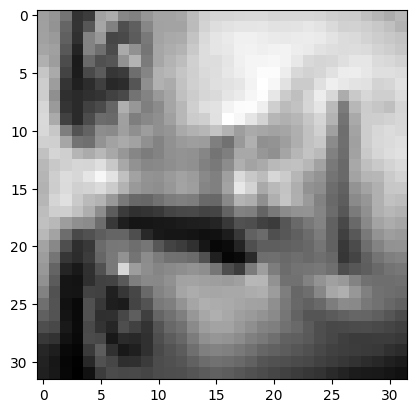

In [1]:
import numpy as np
from scipy.io import loadmat
results=loadmat('yalefaces.mat')
X=results['X']

# print an image of the matrix
import matplotlib.pyplot as plt
plt.imshow(X[:,5].reshape(32,32).T, cmap='gray')
plt.show()

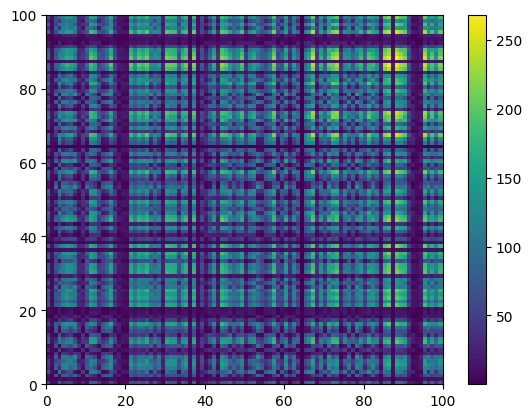

In [2]:
#  Compute a 100×100 correlation matrix C where you will compute the dot product (correlation)
# between the first 100 images in the matrix X. Thus each element is given by cjk = xT
# jxk where xj is
# the jth column of the matrix. Plot the correlation matrix using pcolor.

C=np.zeros((100,100))
for j in range(100):
    for k in range(100):
        # could have used np.dot(X[:,j],X[:,k]) as well
        C[j,k]=X[:,j].T @ X[:,k]
plt.pcolor(C)
plt.colorbar()
plt.show()

# Why do we use the dot product to compute the correlation between two images? The dot product measures the similarity between two vectors (in this case, the pixel values of the images). 
# If the dot product is high, it indicates that the images are similar in terms of their pixel intensity patterns. T
# his is because the dot product sums the products of corresponding pixel values, which will be larger when the images have similar features and patterns.

Most correlated images: (np.int64(86), np.int64(88))
Most uncorrelated images: (np.int64(54), np.int64(64))


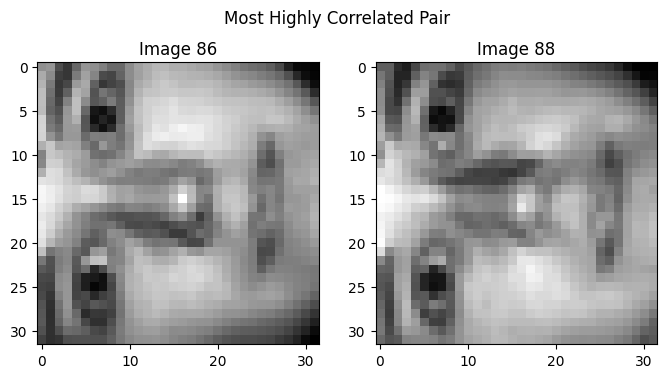

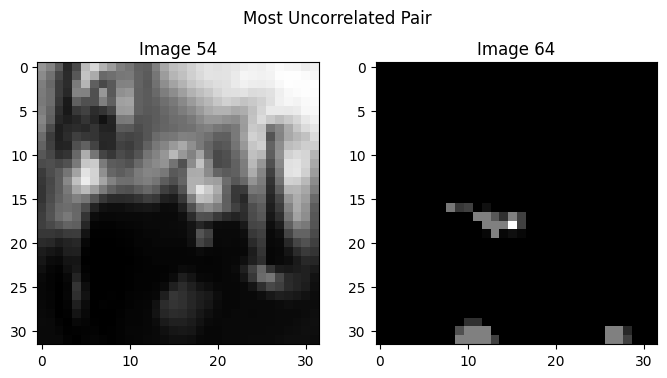

In [3]:
# From the correlation matrix for part (a), which two images are most highly correlated? Which
# are most uncorrelated? Plot these faces.

# We need to exclude the diagonal (self-correlation) when finding the most correlated pair
# Set diagonal to -inf for max search and +inf for min search
C_no_diag = C.copy()
np.fill_diagonal(C_no_diag, -np.inf)
most_correlated = np.unravel_index(np.argmax(C_no_diag, axis=None), C_no_diag.shape)
print("Most correlated images:", most_correlated)

np.fill_diagonal(C_no_diag, np.inf)
most_uncorrelated = np.unravel_index(np.argmin(C_no_diag, axis=None), C_no_diag.shape)
print("Most uncorrelated images:", most_uncorrelated)

# Plot the most correlated images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X[:, most_correlated[0]].reshape(32, 32).T, cmap='gray')
axes[0].set_title(f"Image {most_correlated[0]}")
axes[1].imshow(X[:, most_correlated[1]].reshape(32, 32).T, cmap='gray')
axes[1].set_title(f"Image {most_correlated[1]}")
fig.suptitle("Most Highly Correlated Pair")
plt.show()

# Plot the most uncorrelated images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X[:, most_uncorrelated[0]].reshape(32, 32).T, cmap='gray')
axes[0].set_title(f"Image {most_uncorrelated[0]}")
axes[1].imshow(X[:, most_uncorrelated[1]].reshape(32, 32).T, cmap='gray')
axes[1].set_title(f"Image {most_uncorrelated[1]}")
fig.suptitle("Most Uncorrelated Pair")
plt.show()

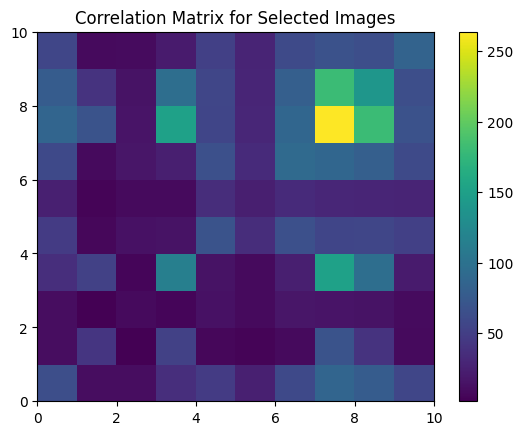

In [4]:
# Repeat part (a) but now compute the 10 ×10 correlation matrix between images and plot the
# correlation matrix between them.
# [1,313,512,5,2400,113,1024,87,314,2005].
# (Just for clarification, the first image is labeled as one, not zero like python might do)
indices = [1, 313, 512, 5, 2400, 113, 1024, 87, 314, 2005]
C_subset = np.zeros((10, 10))
for j in range(10):
    for k in range(10):
        # same as before but now we are using the specified indices to compute the correlation matrix for the selected images
        C_subset[j, k] = X[:, indices[j] - 1].T @ X[:, indices[k] - 1]
plt.pcolor(C_subset)
plt.colorbar()
plt.title("Correlation Matrix for Selected Images")
plt.show()

In [5]:
# (d) Create the matrix Y = XX^T and find the first six eigenvectors with the largest magnitude eigenvalue.
Y = X @ X.T

# Use eigendecomposition on Y (as the assignment asks), not SVD
eigenvalues, eigenvectors = np.linalg.eigh(Y)

# eigh returns eigenvalues in ascending order, so we reverse to get largest first
sorted_indices_eig = np.argsort(np.abs(eigenvalues))[::-1]
top_six_eigenvectors = eigenvectors[:, sorted_indices_eig[:6]]

print("Top six eigenvalues:", eigenvalues[sorted_indices_eig[:6]])
print("\nTop six eigenvectors (first few rows):")
print(top_six_eigenvectors[:5, :])

Top six eigenvalues: [234020.45485389  49038.31530059   8236.53989701   6024.87145793
   2051.49643269   1901.07911482]

Top six eigenvectors (first few rows):
[[-0.02384327 -0.04535378  0.05653196  0.04441826 -0.03378603  0.02207542]
 [-0.02576146 -0.04567536  0.04709124  0.05057969 -0.01791442  0.03378819]
 [-0.02728448 -0.04474528  0.0362807   0.05522219 -0.00462854  0.04487476]
 [-0.0289902  -0.04316163  0.02344727  0.05744188  0.00932899  0.05424285]
 [-0.03057294 -0.04080838  0.00992662  0.05720359  0.02096932  0.06259919]]


In [6]:
# (e) SVD the matrix X and find the first six principal component directions.
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# The first six principal component directions are the first six columns of U
print("First six principal component directions (first few rows):")
print(U[:5, :6])

First six principal component directions (first few rows):
[[-0.02384327 -0.04535378 -0.05653196  0.04441826 -0.03378603  0.02207542]
 [-0.02576146 -0.04567536 -0.04709124  0.05057969 -0.01791442  0.03378819]
 [-0.02728448 -0.04474528 -0.0362807   0.05522219 -0.00462854  0.04487476]
 [-0.0289902  -0.04316163 -0.02344727  0.05744188  0.00932899  0.05424285]
 [-0.03057294 -0.04080838 -0.00992662  0.05720359  0.02096932  0.06259919]]


In [7]:
# (f) Compare the first eigenvector v1 from (d) with the first SVD mode u1 from (e)
# and compute the norm of difference of their absolute values.

v1 = top_six_eigenvectors[:, 0]
u1 = U[:, 0]
difference_norm = np.linalg.norm(np.abs(v1) - np.abs(u1))
print("Norm of the difference between |v1| and |u1|:", difference_norm)

Norm of the difference between |v1| and |u1|: 5.246527690158583e-16


Percentage of variance captured by the first 6 SVD modes:
  Mode 1: 72.93%
  Mode 2: 15.28%
  Mode 3: 2.57%
  Mode 4: 1.88%
  Mode 5: 0.64%
  Mode 6: 0.59%


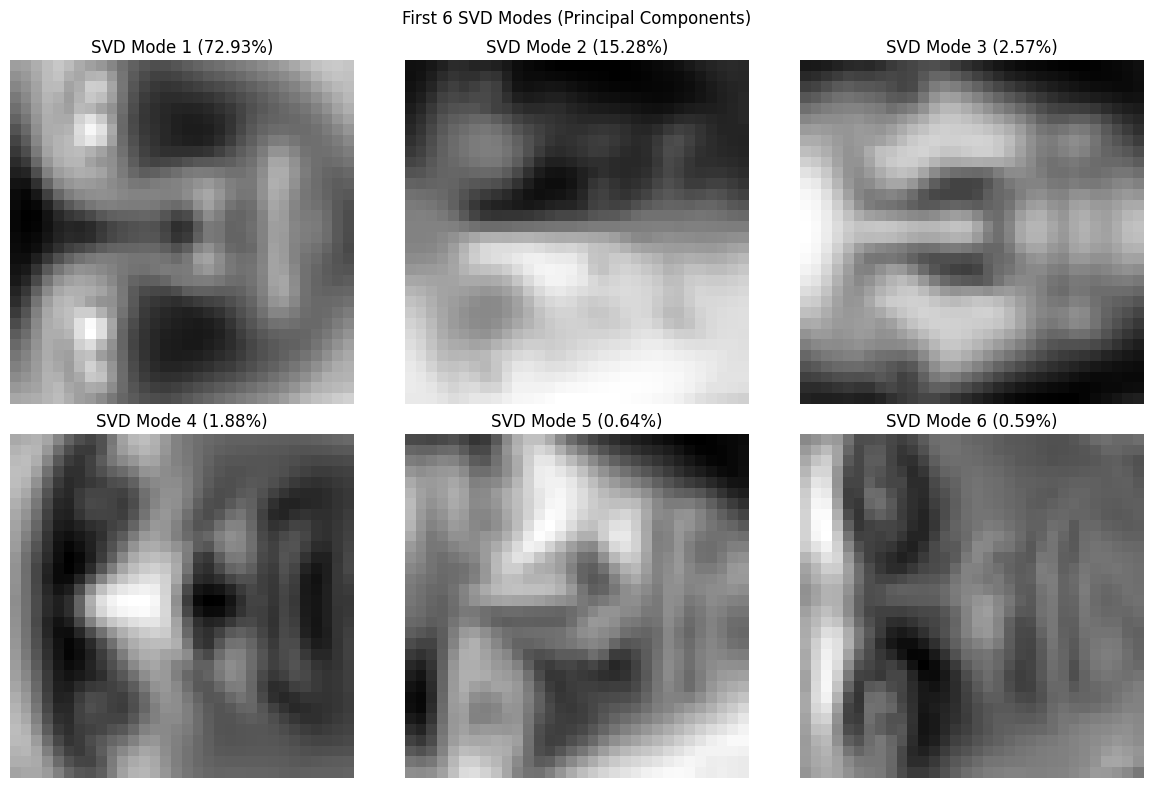

In [8]:
# (g) Compute the percentage of variance captured by each of the first 6 SVD modes.
# Plot the first 6 SVD modes.

variance_captured = (S[:6] ** 2) / np.sum(S ** 2) * 100
print("Percentage of variance captured by the first 6 SVD modes:")
for i, v in enumerate(variance_captured):
    print(f"  Mode {i+1}: {v:.2f}%")

# Plot the first 6 SVD modes as images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(6):
    ax = axes[i // 3, i % 3]
    ax.imshow(U[:, i].reshape(32, 32).T, cmap='gray')
    ax.set_title(f"SVD Mode {i+1} ({variance_captured[i]:.2f}%)")
    ax.axis('off')
plt.suptitle("First 6 SVD Modes (Principal Components)")
plt.tight_layout()
plt.show()